# Tutorial Knowledge Distillation

__Contenido:__
- Definicion
- Paper series de tiempo
- Modelos y arquitecturas a tratar
- Implementación 
- Resultados 


# Definición

La Destilación del conocimiento o knowledge distillation es una técnica para transferir lo que sabe un modelo grande (el "teacher") a un modelo más pequeño (el "student"), de modo que el estudiante alcance rendimiento parecido pero sea más ligero y rápido.

![Grafica de destilación](grafico.png)


# Destilación en problemas de regresión

A diferencia de los modelos de clasificación los modelos de regresión tienen indexado un orden de las observaciones en cada instante de tiempo $t$. No podemos simplemente ponderar la función de perdida de uno y la otra, el paper de Takemoto et al, nos propone la siguiente función de perdida.

\begin{equation}
   L_{TOR}= \begin{cases}
\displaystyle ||R_{s}-t||^2_{2}, & (|t-R_{t}|< \varepsilon_{\text{outlier}})\\[6pt]
\sqrt{R_s - R_t} & (|t-R_{t}|>\varepsilon_{\text{outlier}})\\
\end{cases}
\end{equation}


donde $$\varepsilon_{\text{outlier}} = \sigma \sqrt{-2 \ln \left[\sqrt{2\pi\sigma} \frac{\alpha}{B} \right]}$$

al final tenemos una función de perdida de la siguiente manera, donde $L_{D}$ es la función de pérdida para aprender la predicción del profesor.

$$ L = C_{TOR}L_{TOR} + C_{D}L_{D}$$


# Implementación

### Datos de funcion sinusoidal

In [1]:
# Versión extendida: agrega baseline student (sin distilación) y compara con student distilado.
# Mantengo configuración ligera para que termine rápido en este entorno.
import math, os, sys, time, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# reproducibilidad y rendimiento
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.set_num_threads(1)

device = torch.device("cpu")
print("Device:", device)

# datos sintusoidales con outliers
def make_sinusoid(n_samples=1000, noise_std=0.12, outlier_frac=0.06, x_range=(-5,5)):
    x = np.random.uniform(x_range[0], x_range[1], size=(n_samples,1))
    y = np.sin(x) + np.random.normal(scale=noise_std, size=(n_samples,1))
    n_out = int(outlier_frac * n_samples)
    if n_out>0:
        idx = np.random.choice(n_samples, n_out, replace=False)
        y[idx] += np.random.normal(loc=5.0, scale=3.0, size=(n_out,1))
    return x.astype(np.float32), y.astype(np.float32)

X_train, y_train = make_sinusoid(1000)
X_val, y_val = make_sinusoid(300)
train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_ds = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))
print("Train shape:", X_train.shape, y_train.shape, "Val shape:", X_val.shape, y_val.shape)

Device: cpu
Train shape: (1000, 1) (1000, 1) Val shape: (300, 1) (300, 1)


In [2]:
# modelos
class TeacherMLP(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )
    def forward(self,x): return self.net(x).squeeze(-1)

class StudentMLP(nn.Module):
    def __init__(self, hidden=40):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(1, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
        )
        self.head_Rs = nn.Linear(hidden, 1)
        self.head_Rld = nn.Linear(hidden, 1)
    def forward(self,x):
        h = self.shared(x)
        Rs = self.head_Rs(h).squeeze(-1)
        Rld = self.head_Rld(h).squeeze(-1)
        return Rs, Rld

# baseline student (same architecture but single head)
class BaselineStudent(nn.Module):
    def __init__(self, hidden=40):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )
    def forward(self,x):
        return self.net(x).squeeze(-1)
    
def mae(a,b): return float(np.mean(np.abs(a-b)))
def rmse(a,b): return float(np.sqrt(np.mean((a-b)**2)))

In [3]:
# compute eps via MAD
def estimate_eps_from_teacher(teacher, X_train, y_train, alpha=1.0):
    teacher.eval()
    with torch.no_grad():
        Rt_train = teacher(torch.from_numpy(X_train).to(device)).cpu().numpy().reshape(-1,1)
    diff = (y_train - Rt_train).reshape(-1)
    mad = np.median(np.abs(diff - np.median(diff)))
    sigma_est = 1.4826 * mad
    eps = float(alpha * sigma_est * 2.0 + 1e-12)
    return Rt_train, sigma_est, eps

# TOR loss
def tor_loss(Rs, Rt, t, eps_outlier):
    diff_label_teacher = torch.abs(t - Rt)
    mask_clean = (diff_label_teacher < eps_outlier).float()
    mse_term = (Rs - t).pow(2)
    outlier_term = torch.sqrt(torch.abs(Rs - Rt) + 1e-12)
    loss = mask_clean * mse_term + (1.0 - mask_clean) * outlier_term
    return loss.mean()

In [4]:
def train_teacher(model, train_ds, val_ds, epochs=30, batch_size=64, lr=1e-3):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    tr_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    vl_loader = DataLoader(val_ds, batch_size=1024, shuffle=False)
    best_val = 1e9
    history = {"train_loss":[], "val_mae":[], "val_rmse":[]}
    for ep in range(1, epochs+1):
        model.train(); running=0.0; n=0
        for xb,yb in tr_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            out = model(xb).unsqueeze(-1)
            loss = F.mse_loss(out, yb)
            loss.backward(); opt.step()
            running += float(loss.item())*xb.size(0); n+=xb.size(0)
        train_loss = running/n
        # val
        model.eval()
        with torch.no_grad():
            preds=[]; ys=[]
            for xb,yb in vl_loader:
                xb = xb.to(device)
                p = model(xb).cpu().numpy().reshape(-1,1)
                preds.append(p); ys.append(yb.numpy())
            preds = np.vstack(preds); ys = np.vstack(ys)
            v_mae = mae(preds, ys); v_rmse = rmse(preds, ys)
        history["train_loss"].append(train_loss)
        history["val_mae"].append(v_mae); history["val_rmse"].append(v_rmse)
        if v_mae < best_val:
            best_val = v_mae; torch.save(model.state_dict(), "teacher_best.pth")
        if ep%5==0 or ep==1:
            print(f"[T] Ep {ep}/{epochs} train_loss={train_loss:.5f} val_mae={v_mae:.4f} val_rmse={v_rmse:.4f}")
    model.load_state_dict(torch.load("teacher_best.pth"))
    return history

# train student distilled 
def train_student_distilled(student, teacher, X_train, y_train, train_ds, val_ds, Rt_train_all, eps, epochs=30, batch_size=64, lr=1e-3, c_TOR=1.0, c_D=25.0):
    student.to(device); teacher.to(device); teacher.eval()
    opt = torch.optim.Adam(student.parameters(), lr=lr)
    indexed_train_ds = TensorDataset(torch.from_numpy(X_train.astype(np.float32)), torch.from_numpy(y_train.astype(np.float32)), torch.arange(len(X_train)))
    tr_loader_idx = DataLoader(indexed_train_ds, batch_size=batch_size, shuffle=True)
    vl_loader = DataLoader(val_ds, batch_size=1024, shuffle=False)
    Rt_train_tensor = torch.from_numpy(Rt_train_all.astype(np.float32)).reshape(-1)
    history = {"train_loss":[], "val_mae":[], "val_rmse":[]}
    for ep in range(1, epochs+1):
        student.train(); running=0.0; n=0
        for xb,yb,idx in tr_loader_idx:
            xb, yb, idx = xb.to(device), yb.to(device).squeeze(-1), idx.to(device)
            opt.zero_grad()
            Rs, Rld = student(xb)
            Rt_batch = Rt_train_tensor[idx].to(device).squeeze(-1)
            loss_tor = tor_loss(Rs, Rt_batch, yb, eps_outlier=eps)
            loss_ld = F.l1_loss(Rld, Rt_batch)
            loss = c_TOR * loss_tor + c_D * loss_ld
            loss.backward(); opt.step()
            running += float(loss.item())*xb.size(0); n += xb.size(0)
        train_loss = running/n
        # val
        student.eval()
        with torch.no_grad():
            preds=[]; ys=[]
            for xb,yb in vl_loader:
                xb = xb.to(device)
                Rs, Rld = student(xb)
                p = Rs.cpu().numpy().reshape(-1,1)
                preds.append(p); ys.append(yb.numpy())
            preds = np.vstack(preds); ys = np.vstack(ys)
            v_mae = mae(preds, ys); v_rmse = rmse(preds, ys)
        history["train_loss"].append(train_loss)
        history["val_mae"].append(v_mae); history["val_rmse"].append(v_rmse)
        if ep%5==0 or ep==1:
            print(f"[S-dist] Ep {ep}/{epochs} train_loss={train_loss:.5f} val_mae={v_mae:.4f} val_rmse={v_rmse:.4f}")
    return history, student

# train baseline student basline
def train_student_baseline(baseline, train_ds, val_ds, epochs=30, batch_size=64, lr=1e-3):
    baseline.to(device)
    opt = torch.optim.Adam(baseline.parameters(), lr=lr)
    tr_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    vl_loader = DataLoader(val_ds, batch_size=1024, shuffle=False)
    history = {"train_loss":[], "val_mae":[], "val_rmse":[]}
    best_val = 1e9
    for ep in range(1, epochs+1):
        baseline.train(); running=0.0; n=0
        for xb,yb in tr_loader:
            xb, yb = xb.to(device), yb.to(device).squeeze(-1)
            opt.zero_grad()
            out = baseline(xb)
            loss = F.mse_loss(out, yb)
            loss.backward(); opt.step()
            running += float(loss.item())*xb.size(0); n+=xb.size(0)
        train_loss = running/n
        # val
        baseline.eval()
        with torch.no_grad():
            preds=[]; ys=[]
            for xb,yb in vl_loader:
                xb = xb.to(device)
                p = baseline(xb).cpu().numpy().reshape(-1,1)
                preds.append(p); ys.append(yb.numpy())
            preds = np.vstack(preds); ys = np.vstack(ys)
            v_mae = mae(preds, ys); v_rmse = rmse(preds, ys)
        history["train_loss"].append(train_loss)
        history["val_mae"].append(v_mae); history["val_rmse"].append(v_rmse)
        if v_mae < best_val:
            best_val = v_mae; torch.save(baseline.state_dict(), "baseline_best.pth")
        if ep%5==0 or ep==1:
            print(f"[S-base] Ep {ep}/{epochs} train_loss={train_loss:.5f} val_mae={v_mae:.4f} val_rmse={v_rmse:.4f}")
    baseline.load_state_dict(torch.load("baseline_best.pth"))
    return history, baseline

# evaluación final en validación
def eval_teacher(model, xs, ys):
    model.eval()
    with torch.no_grad():
        p = model(torch.from_numpy(xs)).cpu().numpy().reshape(-1,1)
    return mae(p, ys), rmse(p, ys)

def eval_student_distilled(student, xs, ys):
    student.eval()
    with torch.no_grad():
        Rs, Rld = student(torch.from_numpy(xs))
        p = Rs.cpu().numpy().reshape(-1,1)
    return mae(p, ys), rmse(p, ys)

def eval_baseline(baseline, xs, ys):
    baseline.eval()
    with torch.no_grad():
        p = baseline(torch.from_numpy(xs)).cpu().numpy().reshape(-1,1)
    return mae(p, ys), rmse(p, ys)


Entrenando teacher...
[T] Ep 1/30 train_loss=2.38493 val_mae=0.6286 val_rmse=1.3029
[T] Ep 5/30 train_loss=1.97970 val_mae=0.4551 val_rmse=1.2685
[T] Ep 10/30 train_loss=1.99603 val_mae=0.5350 val_rmse=1.2687
[T] Ep 15/30 train_loss=1.99785 val_mae=0.6851 val_rmse=1.3063
[T] Ep 20/30 train_loss=1.94451 val_mae=0.6183 val_rmse=1.2756
[T] Ep 25/30 train_loss=1.96036 val_mae=0.4681 val_rmse=1.2764
[T] Ep 30/30 train_loss=1.97897 val_mae=0.5710 val_rmse=1.2674
Estimated sigma = 0.230055, eps = 0.460110

Entrenando student (distilled TOR + L_D)...
[S-dist] Ep 1/30 train_loss=17.33822 val_mae=0.9014 val_rmse=1.5063
[S-dist] Ep 5/30 train_loss=15.47593 val_mae=0.8542 val_rmse=1.4525
[S-dist] Ep 10/30 train_loss=13.00059 val_mae=0.7879 val_rmse=1.4054
[S-dist] Ep 15/30 train_loss=7.65796 val_mae=0.6590 val_rmse=1.3334
[S-dist] Ep 20/30 train_loss=2.50392 val_mae=0.5477 val_rmse=1.2975
[S-dist] Ep 25/30 train_loss=0.43748 val_mae=0.4987 val_rmse=1.2778
[S-dist] Ep 30/30 train_loss=0.53285 val_

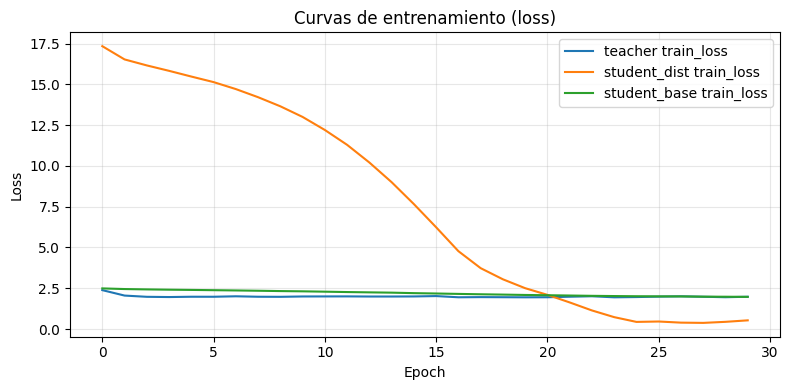

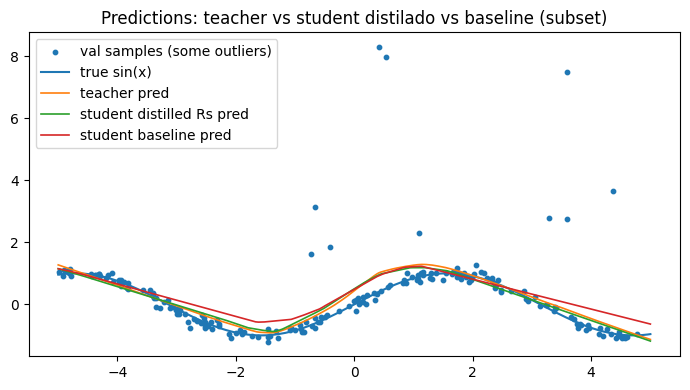

In [5]:
# --- Ejecutar flujo ---
teacher = TeacherMLP(hidden=256)
print("\nEntrenando teacher...")
hist_t = train_teacher(teacher, train_ds, val_ds, epochs=30, batch_size=64, lr=1e-3)

# estimar Rt y eps
Rt_train, sigma_est, eps = estimate_eps_from_teacher(teacher, X_train, y_train, alpha=1.0)
print(f"Estimated sigma = {sigma_est:.6f}, eps = {eps:.6f}")

# entrenar student distilado
student = StudentMLP(hidden=15)
print("\nEntrenando student (distilled TOR + L_D)...")
hist_sdist, student = train_student_distilled(student, teacher, X_train, y_train, train_ds, val_ds, Rt_train, eps, epochs=30, batch_size=64, lr=1e-3, c_TOR=1.0, c_D=25.0)

# entrenar baseline student (sin distilación)
baseline = BaselineStudent(hidden=15)
print("\nEntrenando student baseline (solo labels, MSE)...")
hist_sbase, baseline = train_student_baseline(baseline, train_ds, val_ds, epochs=30, batch_size=64, lr=1e-3)



t_mae, t_rmse = eval_teacher(teacher, X_val, y_val)
sd_mae, sd_rmse = eval_student_distilled(student, X_val, y_val)
sb_mae, sb_rmse = eval_baseline(baseline, X_val, y_val)

print("\nFinal evaluation on validation set:")
print(f"Teacher MAE={t_mae:.4f} RMSE={t_rmse:.4f}")
print(f"Student (distilled) MAE={sd_mae:.4f} RMSE={sd_rmse:.4f}")
print(f"Student (baseline)  MAE={sb_mae:.4f} RMSE={sb_rmse:.4f}")

# plots: pérdidas de los tres entrenamientos
plt.figure(figsize=(8,4))
plt.plot(hist_t["train_loss"], label="teacher train_loss")
plt.plot(hist_sdist["train_loss"], label="student_dist train_loss")
plt.plot(hist_sbase["train_loss"], label="student_base train_loss")
plt.title("Curvas de entrenamiento (loss)")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.show()

# plot predictions subset: ground truth, teacher, student_dist, student_base
with torch.no_grad():
    xs_plot = np.linspace(-5,5,400).reshape(-1,1).astype(np.float32)
    t_pred = teacher(torch.from_numpy(xs_plot)).cpu().numpy().reshape(-1,1)
    sd_Rs, sd_Rld = student(torch.from_numpy(xs_plot))
    sd_pred = sd_Rs.cpu().numpy().reshape(-1,1)
    sb_pred = baseline(torch.from_numpy(xs_plot)).cpu().numpy().reshape(-1,1)

plt.figure(figsize=(7,4))
plt.scatter(X_val[:200], y_val[:200], s=10, label="val samples (some outliers)")
plt.plot(xs_plot, np.sin(xs_plot), linewidth=1.5, label="true sin(x)")
plt.plot(xs_plot, t_pred, linewidth=1.2, label="teacher pred")
plt.plot(xs_plot, sd_pred, linewidth=1.2, label="student distilled Rs pred")
plt.plot(xs_plot, sb_pred, linewidth=1.2, label="student baseline pred")
plt.title("Predictions: teacher vs student distilado vs baseline (subset)")
plt.legend(); plt.tight_layout(); plt.show()

## Datos de diabetes

In [22]:
import pandas as pd
from sklearn.datasets import load_diabetes

diabetes_data = load_diabetes()
df = pd.DataFrame(diabetes_data.data, columns=diabetes_data.feature_names)
df['TEMP'] = diabetes_data.target
df.head(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,TEMP
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
5,-0.092695,-0.044642,-0.040696,-0.019442,-0.068991,-0.079288,0.041277,-0.076395,-0.041176,-0.096346,97.0
6,-0.045472,0.050680,-0.047163,-0.015999,-0.040096,-0.024800,0.000779,-0.039493,-0.062917,-0.038357,138.0
7,0.063504,0.050680,-0.001895,0.066629,0.090620,0.108914,0.022869,0.017703,-0.035816,0.003064,63.0
8,0.041708,0.050680,0.061696,-0.040099,-0.013953,0.006202,-0.028674,-0.002592,-0.014960,0.011349,110.0
9,-0.070900,-0.044642,0.039062,-0.033213,-0.012577,-0.034508,-0.024993,-0.002592,0.067737,-0.013504,310.0


Device: cpu
Shapes: train (282, 10) val (71, 10) test (89, 10)
[T] Ep 1/60 train_loss=28277.5397 val_mae=166.5385 val_rmse=181.9785
[T] Ep 10/60 train_loss=4507.5748 val_mae=56.5245 val_rmse=68.0670
[T] Ep 20/60 train_loss=3178.1318 val_mae=50.3196 val_rmse=61.4864
[T] Ep 30/60 train_loss=2931.4380 val_mae=48.5386 val_rmse=58.7208
[T] Ep 40/60 train_loss=2787.8991 val_mae=47.7164 val_rmse=57.4422
[T] Ep 50/60 train_loss=2697.7620 val_mae=46.6505 val_rmse=56.1192
[T] Ep 60/60 train_loss=2611.1630 val_mae=46.4526 val_rmse=55.7497
Estimated sigma = 46.517633, eps = 93.035265
[S-dist] Ep 1/60 train_loss=28272.4047 val_mae=169.7770 val_rmse=184.9343
[S-dist] Ep 10/60 train_loss=28096.7587 val_mae=169.0850 val_rmse=184.2918
[S-dist] Ep 20/60 train_loss=26688.5205 val_mae=164.2053 val_rmse=179.2852
[S-dist] Ep 30/60 train_loss=21764.2381 val_mae=146.7400 val_rmse=161.1436
[S-dist] Ep 40/60 train_loss=13986.9259 val_mae=113.7228 val_rmse=128.9323
[S-dist] Ep 50/60 train_loss=8503.9907 val_mae=

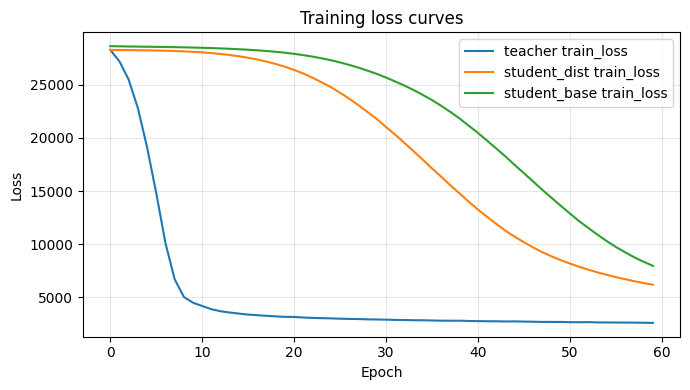

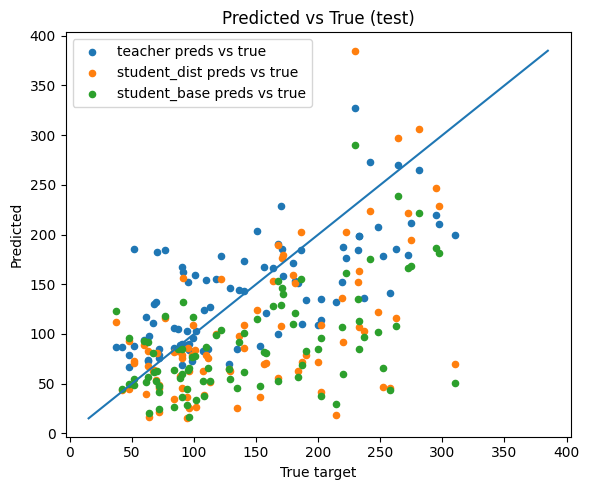

[S-dist] Ep 1/60 train_loss=28129.8734 val_mae=169.1952 val_rmse=184.3862
[S-dist] Ep 10/60 train_loss=27777.4637 val_mae=167.7782 val_rmse=183.0644
[S-dist] Ep 20/60 train_loss=25284.1309 val_mae=158.3056 val_rmse=173.8685
[S-dist] Ep 30/60 train_loss=18020.3583 val_mae=129.1157 val_rmse=145.6972
[S-dist] Ep 40/60 train_loss=8999.9494 val_mae=85.6842 val_rmse=103.1474
[S-dist] Ep 50/60 train_loss=5398.0422 val_mae=67.6796 val_rmse=81.1971
[S-dist] Ep 60/60 train_loss=4384.7515 val_mae=62.6400 val_rmse=75.8966
[S-base] Ep 1/60 train_loss=28647.4718 val_mae=169.5264 val_rmse=184.6899
[S-base] Ep 10/60 train_loss=28142.5259 val_mae=167.8591 val_rmse=182.9401
[S-base] Ep 20/60 train_loss=25177.7022 val_mae=158.2762 val_rmse=172.6417
[S-base] Ep 30/60 train_loss=17803.1543 val_mae=130.5669 val_rmse=144.4245
[S-base] Ep 40/60 train_loss=10669.5168 val_mae=94.6746 val_rmse=110.3086
[S-base] Ep 50/60 train_loss=7511.4401 val_mae=76.3859 val_rmse=92.5391
[S-base] Ep 60/60 train_loss=5942.8088 

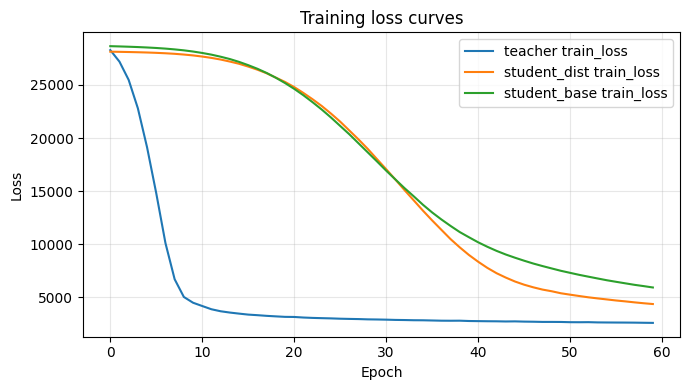

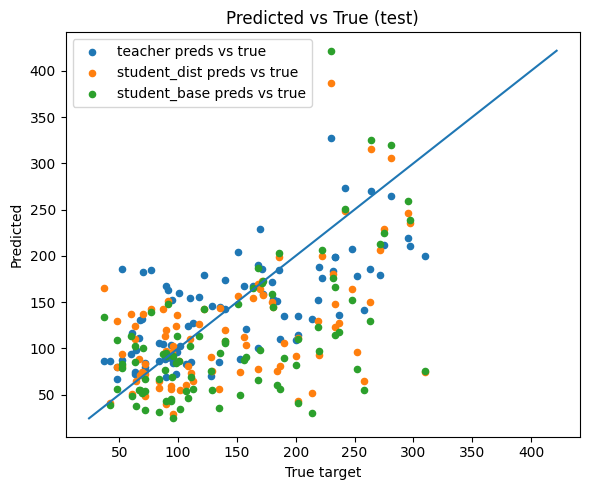

[S-dist] Ep 1/60 train_loss=28141.6468 val_mae=169.2219 val_rmse=184.4098
[S-dist] Ep 10/60 train_loss=27360.1312 val_mae=166.0766 val_rmse=181.5022
[S-dist] Ep 20/60 train_loss=21839.1386 val_mae=144.9216 val_rmse=161.0358
[S-dist] Ep 30/60 train_loss=9900.3795 val_mae=91.0555 val_rmse=108.3154
[S-dist] Ep 40/60 train_loss=4931.1769 val_mae=67.2240 val_rmse=80.5044
[S-dist] Ep 50/60 train_loss=3794.3981 val_mae=62.7424 val_rmse=74.8452
[S-dist] Ep 60/60 train_loss=3100.2496 val_mae=58.6278 val_rmse=70.5441
[S-base] Ep 1/60 train_loss=28635.0375 val_mae=169.4313 val_rmse=184.6220
[S-base] Ep 10/60 train_loss=27814.3924 val_mae=166.5105 val_rmse=181.7288
[S-base] Ep 20/60 train_loss=21999.7618 val_mae=145.5587 val_rmse=160.8456
[S-base] Ep 30/60 train_loss=10074.0085 val_mae=92.3120 val_rmse=108.9436
[S-base] Ep 40/60 train_loss=5466.2868 val_mae=67.8305 val_rmse=81.0564
[S-base] Ep 50/60 train_loss=4595.5967 val_mae=63.3472 val_rmse=75.6640
[S-base] Ep 60/60 train_loss=4092.2149 val_ma

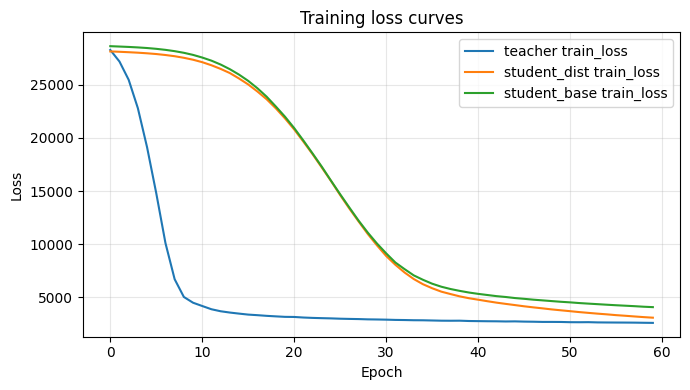

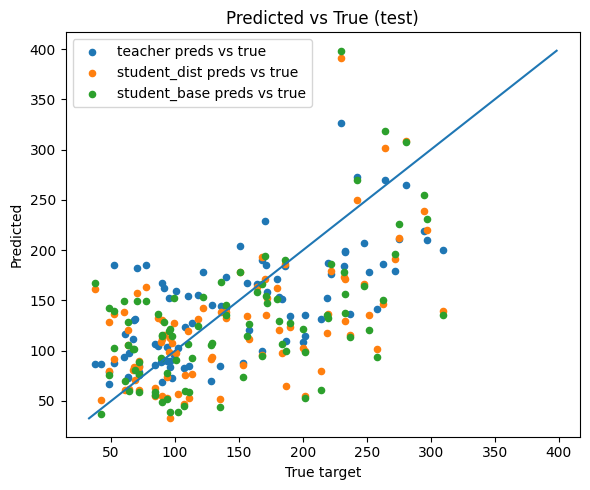

In [32]:
# Entrenamiento comparable usando el dataset "diabetes" de sklearn.
# Flujo: cargar datos, dividir en train/val, estandarizar, entrenar teacher (MLP),
# estimar eps por MAD, entrenar student destilado (TOR + L_D), entrenar baseline student (MSE),
# evaluar MAE/RMSE y mostrar curvas/predicciones.
# Configuración ligera para ejecutarse rápido en este entorno.

import numpy as np
import random, math, time
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# reproducibilidad
seed = 42
random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
torch.set_num_threads(1)
device = torch.device("cpu")
print("Device:", device)

# 1) Cargar y preparar datos (diabetes)
data = load_diabetes()
X = data.data      # (442, 10)
y = data.target.reshape(-1,1)  # (442,1)

# dividir en train/val/test
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.2, random_state=seed)
print("Shapes: train", X_train.shape, "val", X_val.shape, "test", X_test.shape)

# estandarizar características (usando stats del train)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train).astype(np.float32)
X_val_s = scaler.transform(X_val).astype(np.float32)
X_test_s = scaler.transform(X_test).astype(np.float32)
y_train = y_train.astype(np.float32)
y_val = y_val.astype(np.float32)
y_test = y_test.astype(np.float32)

train_ds = TensorDataset(torch.from_numpy(X_train_s), torch.from_numpy(y_train))
val_ds   = TensorDataset(torch.from_numpy(X_val_s), torch.from_numpy(y_val))
test_ds  = TensorDataset(torch.from_numpy(X_test_s), torch.from_numpy(y_test))

# helpers
def mae(a,b): return float(np.mean(np.abs(a-b)))
def rmse(a,b): return float(np.sqrt(np.mean((a-b)**2)))

# 2) Model definitions (input dim = 10)
input_dim = X_train_s.shape[1]

class TeacherMLP(nn.Module):
    def __init__(self, hidden=256, inp=input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(inp, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )
    def forward(self,x): return self.net(x).squeeze(-1)

class StudentMLP(nn.Module):
    def __init__(self, hidden=64, inp=input_dim):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(inp, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
        )
        self.head_Rs = nn.Linear(hidden, 1)
        self.head_Rld = nn.Linear(hidden, 1)
    def forward(self,x):
        h = self.shared(x)
        Rs = self.head_Rs(h).squeeze(-1)
        Rld = self.head_Rld(h).squeeze(-1)
        return Rs, Rld

class BaselineStudent(nn.Module):
    def __init__(self, hidden=64, inp=input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(inp, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )
    def forward(self,x): return self.net(x).squeeze(-1)

# 3) Entrenamiento teacher (MSE)
def train_teacher(model, train_ds, val_ds, epochs=80, batch_size=32, lr=1e-3):
    model.to(device); opt = torch.optim.Adam(model.parameters(), lr=lr)
    tr_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    vl_loader = DataLoader(val_ds, batch_size=256, shuffle=False)
    best = 1e9; history={"train_loss":[], "val_mae":[], "val_rmse":[]}
    for ep in range(1, epochs+1):
        model.train(); running=0.0; n=0
        for xb,yb in tr_loader:
            xb,yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            out = model(xb).unsqueeze(-1)
            loss = F.mse_loss(out, yb)
            loss.backward(); opt.step()
            running += float(loss.item())*xb.size(0); n+=xb.size(0)
        train_loss = running/n
        model.eval()
        with torch.no_grad():
            preds=[]; ys=[]
            for xb,yb in vl_loader:
                p = model(xb.to(device)).cpu().numpy().reshape(-1,1)
                preds.append(p); ys.append(yb.numpy())
            preds = np.vstack(preds); ys = np.vstack(ys)
            v_mae = mae(preds, ys); v_rmse = rmse(preds, ys)
        history["train_loss"].append(train_loss); history["val_mae"].append(v_mae); history["val_rmse"].append(v_rmse)
        if v_mae < best:
            best = v_mae; torch.save(model.state_dict(), "teacher_diabetes_best.pth")
        if ep%10==0 or ep==1:
            print(f"[T] Ep {ep}/{epochs} train_loss={train_loss:.4f} val_mae={v_mae:.4f} val_rmse={v_rmse:.4f}")
    model.load_state_dict(torch.load("teacher_diabetes_best.pth"))
    return history

teacher = TeacherMLP(hidden=256)
hist_t = train_teacher(teacher, train_ds, val_ds, epochs=60, batch_size=32, lr=1e-3)

# 4) Compute Rt for train and estimate eps via MAD
teacher.eval()
with torch.no_grad():
    Rt_train = teacher(torch.from_numpy(X_train_s)).cpu().numpy().reshape(-1,1)
diff = (y_train - Rt_train).reshape(-1)
mad = np.median(np.abs(diff - np.median(diff)))
sigma_est = 1.4826 * mad
alpha = 1.0
eps = float(alpha * sigma_est * 2.0 + 1e-12)
print(f"Estimated sigma = {sigma_est:.6f}, eps = {eps:.6f}")

# 5) TOR loss
def tor_loss(Rs, Rt, t, eps_outlier):
    diff_label_teacher = torch.abs(t - Rt)
    mask_clean = (diff_label_teacher < eps_outlier).float()
    mse_term = (Rs - t).pow(2)
    outlier_term = torch.sqrt(torch.abs(Rs - Rt) + 1e-12)
    loss = mask_clean * mse_term + (1.0 - mask_clean) * outlier_term
    return loss.mean()

# 6) Train student distilled (TOR + L_D)
def train_student_distilled(student, teacher, X_train_s, y_train, train_ds, val_ds, Rt_train_all, eps, epochs=60, batch_size=32, lr=1e-3, c_TOR=1.0, c_D=25.0):
    student.to(device); teacher.to(device); teacher.eval()
    opt = torch.optim.Adam(student.parameters(), lr=lr)
    indexed_train_ds = TensorDataset(torch.from_numpy(X_train_s.astype(np.float32)), torch.from_numpy(y_train.astype(np.float32)), torch.arange(len(X_train_s)))
    tr_loader_idx = DataLoader(indexed_train_ds, batch_size=batch_size, shuffle=True)
    vl_loader = DataLoader(val_ds, batch_size=256, shuffle=False)
    Rt_train_tensor = torch.from_numpy(Rt_train_all.astype(np.float32)).reshape(-1)
    history={"train_loss":[], "val_mae":[], "val_rmse":[]}
    for ep in range(1, epochs+1):
        student.train(); running=0.0; n=0
        for xb,yb,idx in tr_loader_idx:
            xb,yb,idx = xb.to(device), yb.to(device).squeeze(-1), idx.to(device)
            opt.zero_grad()
            Rs, Rld = student(xb)
            Rt_batch = Rt_train_tensor[idx].to(device).squeeze(-1)
            loss_tor = tor_loss(Rs, Rt_batch, yb, eps_outlier=eps)
            loss_ld = F.l1_loss(Rld, Rt_batch)
            loss = c_TOR * loss_tor + c_D * loss_ld
            loss.backward(); opt.step()
            running += float(loss.item())*xb.size(0); n += xb.size(0)
        train_loss = running/n
        student.eval()
        with torch.no_grad():
            preds=[]; ys=[]
            for xb,yb in DataLoader(val_ds, batch_size=256, shuffle=False):
                Rs, Rld = student(xb.to(device))
                p = Rs.cpu().numpy().reshape(-1,1)
                preds.append(p); ys.append(yb.numpy())
            preds = np.vstack(preds); ys = np.vstack(ys)
            v_mae = mae(preds, ys); v_rmse = rmse(preds, ys)
        history["train_loss"].append(train_loss); history["val_mae"].append(v_mae); history["val_rmse"].append(v_rmse)
        if ep%10==0 or ep==1:
            print(f"[S-dist] Ep {ep}/{epochs} train_loss={train_loss:.4f} val_mae={v_mae:.4f} val_rmse={v_rmse:.4f}")
    return history, student

# 7) Train baseline student (MSE only)
def train_student_baseline(baseline, train_ds, val_ds, epochs=60, batch_size=32, lr=1e-3):
    baseline.to(device); opt = torch.optim.Adam(baseline.parameters(), lr=lr)
    tr_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    vl_loader = DataLoader(val_ds, batch_size=256, shuffle=False)
    history={"train_loss":[], "val_mae":[], "val_rmse":[]}
    best = 1e9
    for ep in range(1, epochs+1):
        baseline.train(); running=0.0; n=0
        for xb,yb in tr_loader:
            xb,yb = xb.to(device), yb.to(device).squeeze(-1)
            opt.zero_grad()
            out = baseline(xb)
            loss = F.mse_loss(out, yb)
            loss.backward(); opt.step()
            running += float(loss.item())*xb.size(0); n+=xb.size(0)
        train_loss = running/n
        baseline.eval()
        with torch.no_grad():
            preds=[]; ys=[]
            for xb,yb in vl_loader:
                p = baseline(xb.to(device)).cpu().numpy().reshape(-1,1)
                preds.append(p); ys.append(yb.numpy())
            preds = np.vstack(preds); ys = np.vstack(ys)
            v_mae = mae(preds, ys); v_rmse = rmse(preds, ys)
        history["train_loss"].append(train_loss); history["val_mae"].append(v_mae); history["val_rmse"].append(v_rmse)
        if v_mae < best:
            best = v_mae; torch.save(baseline.state_dict(), "baseline_diabetes_best.pth")
        if ep%10==0 or ep==1:
            print(f"[S-base] Ep {ep}/{epochs} train_loss={train_loss:.4f} val_mae={v_mae:.4f} val_rmse={v_rmse:.4f}")
    baseline.load_state_dict(torch.load("baseline_diabetes_best.pth"))
    return history, baseline


# 8) Evaluación final en test set
def eval_teacher(model, Xs, ys):
    model.eval()
    with torch.no_grad():
        p = model(torch.from_numpy(Xs)).cpu().numpy().reshape(-1,1)
    return mae(p, ys), rmse(p, ys), p

def eval_student_distilled(student, Xs, ys):
    student.eval()
    with torch.no_grad():
        Rs, Rld = student(torch.from_numpy(Xs))
        p = Rs.cpu().numpy().reshape(-1,1)
    return mae(p, ys), rmse(p, ys), p

def eval_baseline(baseline, Xs, ys):
    baseline.eval()
    with torch.no_grad():
        p = baseline(torch.from_numpy(Xs)).cpu().numpy().reshape(-1,1)
    return mae(p, ys), rmse(p, ys), p


layers_students= [10,15, 25]
for i in layers_students:
    student = StudentMLP(hidden=i)
    hist_sdist, student = train_student_distilled(student, teacher, X_train_s, y_train, train_ds, val_ds, Rt_train, eps, epochs=60, batch_size=32, lr=1e-3, c_TOR=1.0, c_D=25.0)
    baseline = BaselineStudent(hidden=i)
    hist_sbase, baseline = train_student_baseline(baseline, train_ds, val_ds, epochs=60, batch_size=32, lr=1e-3)

    t_mae, t_rmse, t_pred = eval_teacher(teacher, X_test_s, y_test)
    sd_mae, sd_rmse, sd_pred = eval_student_distilled(student, X_test_s, y_test)
    sb_mae, sb_rmse, sb_pred = eval_baseline(baseline, X_test_s, y_test)

    print("\nTest set results:")
    print(f"Teacher MAE={t_mae:.4f} RMSE={t_rmse:.4f}")
    print(f"Student distilled MAE={sd_mae:.4f} RMSE={sd_rmse:.4f}")
    print(f"Student baseline  MAE={sb_mae:.4f} RMSE={sb_rmse:.4f}")

    # 9) Plots: (a) train losses, (b) true vs predicted scatter (test)
    plt.figure(figsize=(7,4))
    plt.plot(hist_t["train_loss"], label="teacher train_loss")
    plt.plot(hist_sdist["train_loss"], label="student_dist train_loss")
    plt.plot(hist_sbase["train_loss"], label="student_base train_loss")
    plt.title("Training loss curves"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

    plt.figure(figsize=(6,5))
    plt.scatter(y_test, t_pred, s=20, label="teacher preds vs true")
    plt.scatter(y_test, sd_pred, s=20, label="student_dist preds vs true")
    plt.scatter(y_test, sb_pred, s=20, label="student_base preds vs true")
    minv = min(y_test.min(), t_pred.min(), sd_pred.min(), sb_pred.min())
    maxv = max(y_test.max(), t_pred.max(), sd_pred.max(), sb_pred.max())
    plt.plot([minv, maxv], [minv, maxv])
    plt.xlabel("True target"); plt.ylabel("Predicted"); plt.title("Predicted vs True (test)") 
    plt.legend(); plt.tight_layout(); plt.show()
